##### Copyright 2021 The TensorFlow Authors.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Transfer learning with YAMNet for environmental sound classification

[YAMNet](https://tfhub.dev/google/yamnet/1) is a pre-trained deep neural network that can predict audio events from [521 classes](https://github.com/tensorflow/models/blob/master/research/audioset/yamnet/yamnet_class_map.csv), such as laughter, barking, or a siren. 

 In this tutorial you will learn how to:

- Load and use the YAMNet model for inference.
- Build a new model using the YAMNet embeddings to classify cat and dog sounds.
- Evaluate and export your model.


## Import TensorFlow and other libraries


Start by installing [TensorFlow I/O](https://www.tensorflow.org/io), which will make it easier for you to load audio files off disk.

In [2]:
import pandas as pd
import plotly.express as px
import os

from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio
from tensorflow.keras import regularizers

import params as yamnet_params
import yamnet as yamnet_model

In [3]:
params = yamnet_params.Params()
yamnet = yamnet_model.yamnet_frames_model(params)
yamnet.load_weights('yamnet.h5')
yamnet_classes = yamnet_model.class_names('yamnet_class_map.csv')

In [4]:
# testing if everything is working:
yamnet.summary()

Model: "yamnet_frames"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None,)]            0           []                               
                                                                                                  
 tf.compat.v1.shape (TFOpLambda  (1,)                0           ['input_1[0][0]']                
 )                                                                                                
                                                                                                  
 tf.__operators__.getitem (Slic  ()                  0           ['tf.compat.v1.shape[0][0]']     
 ingOpLambda)                                                                                     
                                                                                      

In [5]:
# Utility functions for loading audio files and making sure the sample rate is correct.

@tf.function
def load_wav_16k_mono(filename):
    """ Load a WAV file, convert it to a float tensor, resample to 16 kHz single-channel audio. """
    file_contents = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(
          file_contents,
          desired_channels=1)
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

### train

In [6]:
base_data_path = r"D:\AUDIOSET_STRONG"

train_path = r"train_16k_trimmed_logging"

train_csv = r"C:\Users\GIS2\Documents\santi\GitHub\AAC\AI_Model\Fine-Tuning_Models\66_classes_port\transfer-learning-scratch\yamnet\audioset_train_strong_filt_downloaded.csv"

pd_train = pd.read_csv(os.path.join(base_data_path, train_csv))
pd_train.head()

,Unnamed: 0,segment_id,start_time_seconds,end_time_seconds,label,duration,clip_id,filename,index,mid,display_name
0,0,b0RFKhbpFJA_30000,0.000,10.000,/m/03m9d0z,10.000,0x7b99cd732dabfef0,0x7b99cd732dabfef0.wav,277,/m/03m9d0z,Wind
1,152,ZvAdd4Jb1xA_30000,0.000,10.000,/m/03m9d0z,10.000,-0x6da6a8a6c54e3ad,-0x6da6a8a6c54e3ad.wav,277,/m/03m9d0z,Wind
2,169,sWdJR9dInhw_19000,0.000,9.803,/m/03m9d0z,9.803,-0x52b316ded52fb65e,-0x52b316ded52fb65e.wav,277,/m/03m9d0z,Wind
3,250,3zOfKHtXxws_30000,0.000,10.000,/m/03m9d0z,10.000,0x4ea20c5a7d1cf994,0x4ea20c5a7d1cf994.wav,277,/m/03m9d0z,Wind
4,314,0r4zxu38gt0_0,0.083,10.000,/m/03m9d0z,9.917,0x5a0670380b88cad7,0x5a0670380b88cad7.wav,277,/m/03m9d0z,Wind


In [7]:
# remove label columns
pd_train = pd_train.drop(columns=['label', 'index', 'Unnamed: 0', 'clip_id', 'start_time_seconds', 'end_time_seconds'])
pd_train.head()

,segment_id,duration,filename,mid,display_name
0,b0RFKhbpFJA_30000,10.000,0x7b99cd732dabfef0.wav,/m/03m9d0z,Wind
1,ZvAdd4Jb1xA_30000,10.000,-0x6da6a8a6c54e3ad.wav,/m/03m9d0z,Wind
2,sWdJR9dInhw_19000,9.803,-0x52b316ded52fb65e.wav,/m/03m9d0z,Wind
3,3zOfKHtXxws_30000,10.000,0x4ea20c5a7d1cf994.wav,/m/03m9d0z,Wind
4,0r4zxu38gt0_0,9.917,0x5a0670380b88cad7.wav,/m/03m9d0z,Wind


In [8]:
# check if the audio files exist
total_files = len(pd_train)
print("Checking files in: ", base_data_path)
print("\nTotal files: ", total_files)
print()

for index, row in pd_train.iterrows():
    file_path = row['filename']
    
    # join the path and filename
    file_path = os.path.join(base_data_path, train_path, file_path)
    
    if not os.path.isfile(file_path):
        print("file not found: ", file_path)
        pd_train.drop(index, inplace=True)

pd_train = pd_train.drop_duplicates(subset=['filename'])

total_files_after = len(pd_train)
print("\nTotal files after checking: ", total_files_after)

total_files_removed = total_files - total_files_after
print("\nTotal files removed: ", total_files_removed)

Checking files in:  D:\AUDIOSET_STRONG

Total files:  141264

file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0x74b2cac4f03e01cb.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\-0x513a3c9139d960a4.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\-0x392001de53e09c77.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\-0x7dbeae7cce955e24.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\-0x354dd3237cef2857.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\-0x1717836c3b156afb.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0x5f5d0798106e7ca9.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0x5a612109bb83d08c.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0x68c6d100346464dc.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0x2db64462b50a4bb2.wav
file not found:  D:\AUDIOSET_STRONG\train_16k_trimmed_logging\-0x18855ee9f3b087ad.w

In [9]:
lenght_train_df = (len(pd_train))
print("Total files in train: ", lenght_train_df)

# list files in the directory to check if the files are there
# in this dir D:\AUDIOSET_STRONG\train_16k_trimmed_logging

files = os.listdir(os.path.join(base_data_path, train_path))
lenght_folder_train_df = (len(files))
print("Total files in train folder: ", lenght_folder_train_df)

print("Difference between train folder and train df: ", lenght_train_df - lenght_folder_train_df)

Total files in train:  137698
Total files in train folder:  137698
Difference between train folder and train df:  0


In [10]:
# label the folds for evaluation.
# 1. get the unique labels
labels = pd_train['display_name'].unique()
# print(labels)
print("Total labels: ", len(labels))

# 2. create a dictionary with the labels
label_dict = {}
for index, label in enumerate(labels):
    label_dict[label] = index
    
print(label_dict)

# count the number of files per label
label_count = {}
for index, row in pd_train.iterrows():
    label = row['display_name']
    if label in label_count:
        label_count[label] += 1
    else:
        label_count[label] = 1
        
print(f"\nThis is the count for labels:\n {label_count}")

Total labels:  63
{'Wind': 0, 'Shout': 1, 'Mechanisms': 2, 'Bark': 3, 'Conversation': 4, 'Speech': 5, 'Dog': 6, 'Bird vocalization, bird call, bird song': 7, 'Bird': 8, 'Wind noise (microphone)': 9, 'Chirp, tweet': 10, 'Engine starting': 11, 'Hubbub, speech noise, speech babble': 12, 'Motor vehicle (road)': 13, 'Car': 14, 'Car alarm': 15, 'Medium engine (mid frequency)': 16, 'Water': 17, 'Rain': 18, 'Alarm': 19, 'Ocean': 20, 'Ship': 21, 'Light engine (high frequency)': 22, 'Tools': 23, 'Truck': 24, 'Thump, thud': 25, 'Traffic noise, roadway noise': 26, 'Screaming': 27, 'Motorcycle': 28, 'Squeak': 29, 'Reversing beeps': 30, 'Ambulance (siren)': 31, 'Clang': 32, 'Engine': 33, 'Waves, surf': 34, 'Whistle': 35, 'Siren': 36, 'Stream': 37, 'Mechanical fan': 38, 'Air horn, truck horn': 39, 'Rain on surface': 40, 'Engine knocking': 41, 'Car passing by': 42, 'Air brake': 43, 'Vehicle horn, car horn, honking': 44, 'Emergency vehicle': 45, 'Rumble': 46, 'Thunk': 47, 'Buzzer': 48, 'Gears': 49, 'Sa

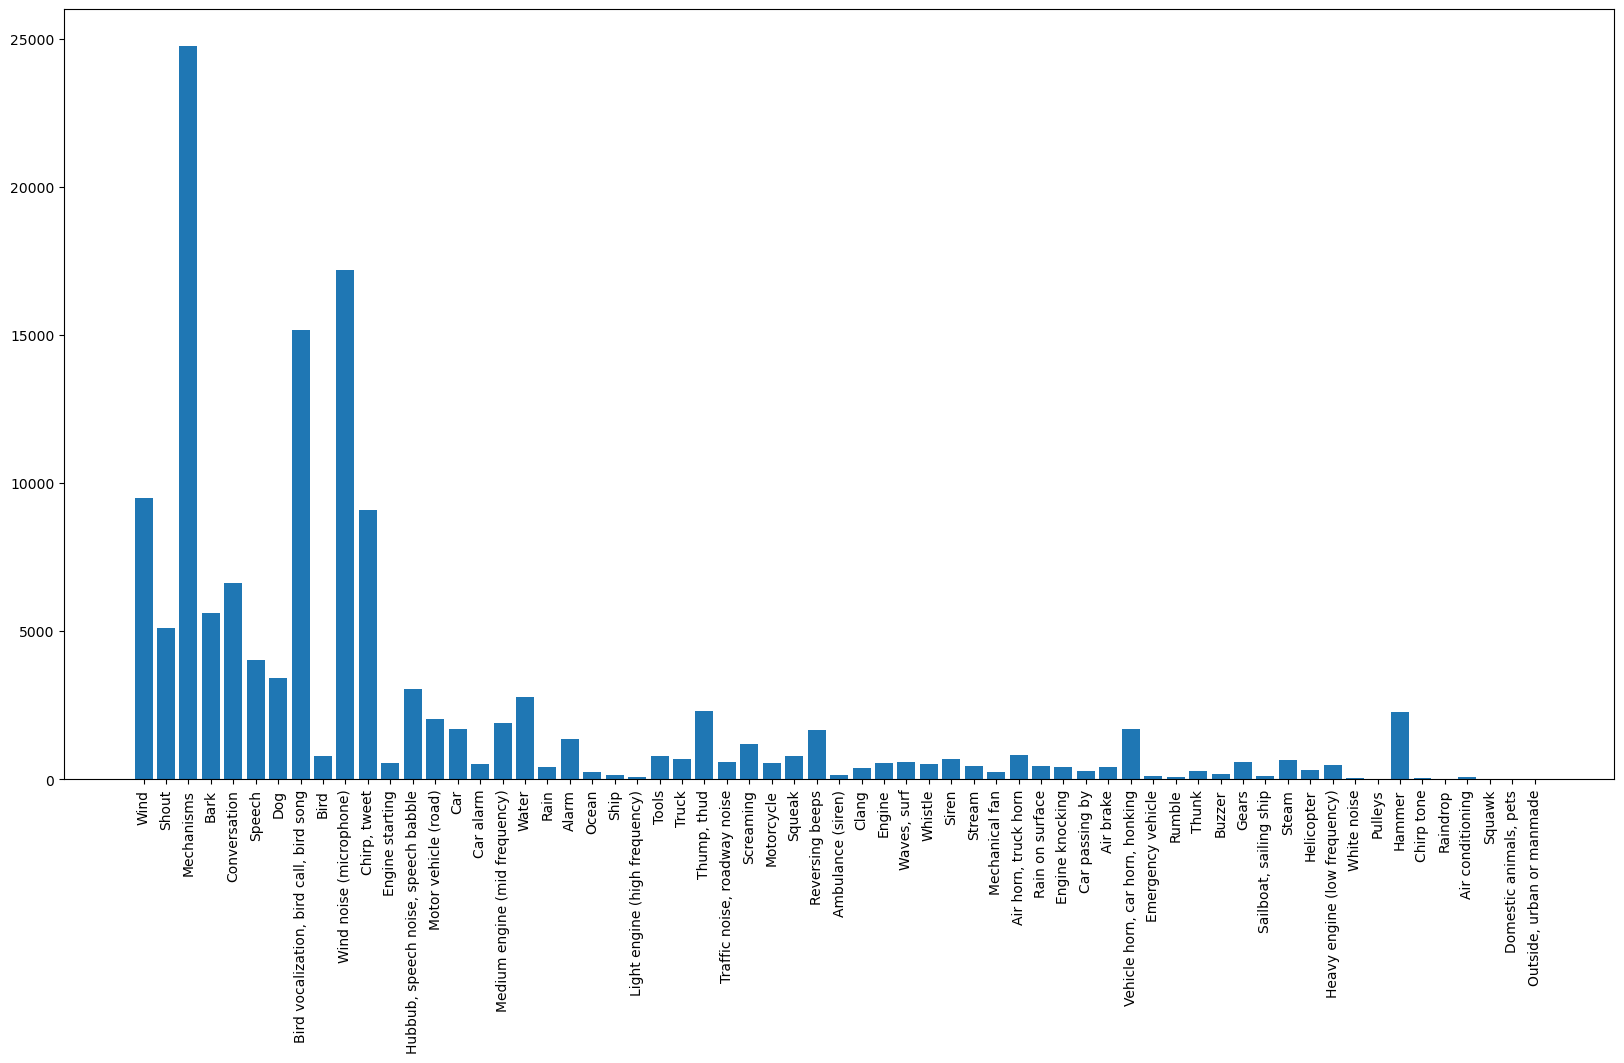

In [11]:
# plot the label count
plt.figure(figsize=(20,10))
plt.bar(label_count.keys(), label_count.values())
plt.xticks(rotation=90)
plt.show()

In [12]:
label_count = pd_train['display_name'].value_counts().to_dict()

pd_train['fold'] = 0

for label, count in label_count.items():
    # calculate the number of samples for each fold
    num_train = int(count * 0.8)
    num_eval = int(count * 0.1)

    indices = pd_train[pd_train['display_name'] == label].index

    pd_train.loc[indices[:num_train], 'fold'] = 1  # 80% for training
    pd_train.loc[indices[num_train:num_train + num_eval], 'fold'] = 2  # 10% for evaluation
    pd_train.loc[indices[num_train + num_eval:], 'fold'] = 3  # remaining 10% for testing

fold_distribution = pd_train['fold'].value_counts(normalize=True)

fold_distribution, pd_train.head()

(1    0.799830
 3    0.100357
 2    0.099813
 Name: fold, dtype: float64,
           segment_id  duration                 filename         mid  \
 0  b0RFKhbpFJA_30000    10.000   0x7b99cd732dabfef0.wav  /m/03m9d0z   
 1  ZvAdd4Jb1xA_30000    10.000   -0x6da6a8a6c54e3ad.wav  /m/03m9d0z   
 2  sWdJR9dInhw_19000     9.803  -0x52b316ded52fb65e.wav  /m/03m9d0z   
 3  3zOfKHtXxws_30000    10.000   0x4ea20c5a7d1cf994.wav  /m/03m9d0z   
 4      0r4zxu38gt0_0     9.917   0x5a0670380b88cad7.wav  /m/03m9d0z   
 
   display_name  fold  
 0         Wind     1  
 1         Wind     1  
 2         Wind     1  
 3         Wind     1  
 4         Wind     1  )

In [13]:
pd_train

,segment_id,duration,filename,mid,display_name,fold
0,b0RFKhbpFJA_30000,10.000,0x7b99cd732dabfef0.wav,/m/03m9d0z,Wind,1
1,ZvAdd4Jb1xA_30000,10.000,-0x6da6a8a6c54e3ad.wav,/m/03m9d0z,Wind,1
2,sWdJR9dInhw_19000,9.803,-0x52b316ded52fb65e.wav,/m/03m9d0z,Wind,1
3,3zOfKHtXxws_30000,10.000,0x4ea20c5a7d1cf994.wav,/m/03m9d0z,Wind,1
4,0r4zxu38gt0_0,9.917,0x5a0670380b88cad7.wav,/m/03m9d0z,Wind,1
...,...,...,...,...,...,...
141259,pomUWYaREso_20000,1.078,0x64108f4c27c01c8f.wav,/m/068hy,"Domestic animals, pets",2
141260,pomUWYaREso_20000,0.960,0x46642ec89d316ae6.wav,/m/068hy,"Domestic animals, pets",3
141261,pomUWYaREso_20000,0.441,0x1d60034a9896521b.wav,/m/068hy,"Domestic animals, pets",3
141262,pomUWYaREso_20000,0.567,-0x6692ad1da5309aa4.wav,/m/068hy,"Domestic animals, pets",3


In [14]:
# save the new csv
pd_train.to_csv(os.path.join(base_data_path, "audioset_66_classes_folds_trimmed.csv"))

In [15]:
class_counts = pd_train['display_name'].value_counts().reset_index()
class_counts.columns = ['display_name', 'count']

fig = px.treemap(class_counts, 
                 path=['display_name'], 
                 values='count',
                 title='Distribution of Audio Classes in the TRAIN Dataset')

fig.show()

In [16]:
unique_classes = pd_train['display_name'].unique()

equal_value_df = pd.DataFrame({'display_name': unique_classes, 'value': 1})

fig = px.treemap(equal_value_df, 
                 path=['display_name'], 
                 values='value',
                 title='Equal Proportion Treemap of Audio Classes in the TRAIN Dataset')

fig.show()

In [17]:
print(f"These are the in the train dataset: \n\n{pd_train['display_name'].unique()}")

print(f"\nThere are {len(pd_train['display_name'].unique())} classes in the train dataset")

These are the in the train dataset: 

['Wind' 'Shout' 'Mechanisms' 'Bark' 'Conversation' 'Speech' 'Dog'
 'Bird vocalization, bird call, bird song' 'Bird'
 'Wind noise (microphone)' 'Chirp, tweet' 'Engine starting'
 'Hubbub, speech noise, speech babble' 'Motor vehicle (road)' 'Car'
 'Car alarm' 'Medium engine (mid frequency)' 'Water' 'Rain' 'Alarm'
 'Ocean' 'Ship' 'Light engine (high frequency)' 'Tools' 'Truck'
 'Thump, thud' 'Traffic noise, roadway noise' 'Screaming' 'Motorcycle'
 'Squeak' 'Reversing beeps' 'Ambulance (siren)' 'Clang' 'Engine'
 'Waves, surf' 'Whistle' 'Siren' 'Stream' 'Mechanical fan'
 'Air horn, truck horn' 'Rain on surface' 'Engine knocking'
 'Car passing by' 'Air brake' 'Vehicle horn, car horn, honking'
 'Emergency vehicle' 'Rumble' 'Thunk' 'Buzzer' 'Gears'
 'Sailboat, sailing ship' 'Steam' 'Helicopter'
 'Heavy engine (low frequency)' 'White noise' 'Pulleys' 'Hammer'
 'Chirp tone' 'Raindrop' 'Air conditioning' 'Squawk'
 'Domestic animals, pets' 'Outside, urban or ma

In [18]:
port_66_classes = ['Wind', 'Shout', 'Mechanisms', 'Bark', 'Conversation', 'Speech',
                 'Dog', 'Bird vocalization, bird call, bird song', 'Bird',
                 'Wind noise (microphone)', 'Chirp, tweet', 'Engine starting',
                 'Hubbub, speech noise, speech babble', 'Motor vehicle (road)', 'Car',
                 'Car alarm', 'Medium engine (mid frequency)', 'Water', 'Rain', 'Alarm',
                 'Ocean', 'Ship', 'Light engine (high frequency)', 'Tools', 'Truck',
                 'Thump, thud', 'Traffic noise, roadway noise', 'Screaming', 'Motorcycle',
                 'Squeak', 'Reversing beeps', 'Ambulance (siren)', 'Clang', 'Engine',
                 'Waves, surf', 'Whistle', 'Siren', 'Stream', 'Mechanical fan',
                 'Air horn, truck horn', 'Rain on surface', 'Engine knocking',
                 'Car passing by', 'Air brake', 'Vehicle horn, car horn, honking',
                 'Emergency vehicle', 'Rumble', 'Thunk', 'Buzzer', 'Gears',
                 'Sailboat, sailing ship', 'Steam', 'Helicopter',
                 'Heavy engine (low frequency)', 'White noise', 'Pulleys', 'Hammer',
                 'Chirp tone', 'Raindrop', 'Air conditioning', 'Squawk',
                 'Domestic animals, pets', 'Outside, urban or manmade']

port_66_classes_to_id = {'Wind':0, 'Shout':1, 'Mechanisms':2, 'Bark':3, 'Conversation':4, 'Speech':5,
                 'Dog':6, 'Bird vocalization, bird call, bird song':7, 'Bird':8,
                 'Wind noise (microphone)':9, 'Chirp, tweet':10, 'Engine starting':11,
                 'Hubbub, speech noise, speech babble':12, 'Motor vehicle (road)':13, 'Car':14,
                 'Car alarm':15, 'Medium engine (mid frequency)':16, 'Water':17, 'Rain':18, 'Alarm':19,
                 'Ocean':20, 'Ship':21, 'Light engine (high frequency)':22, 'Tools':23, 'Truck':24,
                 'Thump, thud':25, 'Traffic noise, roadway noise':26, 'Screaming':27, 'Motorcycle':28,
                 'Squeak':29, 'Reversing beeps':30, 'Ambulance (siren)':31, 'Clang':32, 'Engine':33,
                 'Waves, surf':34, 'Whistle':35, 'Siren':36, 'Stream':37, 'Mechanical fan':38,
                 'Air horn, truck horn':39, 'Rain on surface':40, 'Engine knocking':41,
                 'Car passing by':42, 'Air brake':43, 'Vehicle horn, car horn, honking':44,
                 'Emergency vehicle':45, 'Rumble':46, 'Thunk':47, 'Buzzer':48, 'Gears':49,
                 'Sailboat, sailing ship':50, 'Steam':51, 'Helicopter':52,
                 'Heavy engine (low frequency)':53, 'White noise':54, 'Pulleys':55, 'Hammer':56,
                 'Chirp tone':57, 'Raindrop':58, 'Air conditioning':59, 'Squawk':60,
                 'Domestic animals, pets':61, 'Outside, urban or manmade':62}

In [19]:
filtered_pd = pd_train[pd_train.display_name.isin(port_66_classes)]

class_id = filtered_pd['display_name'].apply(lambda name: port_66_classes_to_id[name])
filtered_pd = filtered_pd.assign(target=class_id)

full_path = filtered_pd['filename'].apply(lambda name: os.path.join(base_data_path, train_path, name))
filtered_pd = filtered_pd.assign(filename=full_path)

# rename the column display_name to category
filtered_pd.rename(columns={'display_name': 'category'}, inplace=True)

# move column order: filename	fold	target	category
filtered_pd = filtered_pd[['filename', 'fold', 'target', 'category', 'segment_id', 'duration']]

filtered_pd

,filename,fold,target,category,segment_id,duration
0,D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,1,0,Wind,b0RFKhbpFJA_30000,10.000
1,D:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,1,0,Wind,ZvAdd4Jb1xA_30000,10.000
2,D:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,1,0,Wind,sWdJR9dInhw_19000,9.803
3,D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,1,0,Wind,3zOfKHtXxws_30000,10.000
4,D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,1,0,Wind,0r4zxu38gt0_0,9.917
...,...,...,...,...,...,...
141259,D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,2,61,"Domestic animals, pets",pomUWYaREso_20000,1.078
141260,D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,3,61,"Domestic animals, pets",pomUWYaREso_20000,0.960
141261,D:\AUDIOSET_STRONG\train_16k_trimmed_logging\0...,3,61,"Domestic animals, pets",pomUWYaREso_20000,0.441
141262,D:\AUDIOSET_STRONG\train_16k_trimmed_logging\-...,3,61,"Domestic animals, pets",pomUWYaREso_20000,0.567


In [20]:
#  print values of fold!
print(filtered_pd['fold'].unique())

[1 2 3]


In [21]:
for index, row in filtered_pd.iterrows():
    # check if the file exists
    if not os.path.isfile(row['filename']):
        print("file not found: ", row['filename'])
        filtered_pd.drop(index, inplace=True)

In [22]:
filenames = filtered_pd['filename']
targets = filtered_pd['target']
folds = filtered_pd['fold']

main_ds = tf.data.Dataset.from_tensor_slices((filenames, targets, folds))
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [23]:
def load_wav_for_map(filename, label, fold):
  return load_wav_16k_mono(filename), label, fold

main_ds = main_ds.map(load_wav_for_map)
main_ds.element_spec

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [24]:
# applies the embedding extraction model to a wav data
def extract_embedding(wav_data, label, fold):
  ''' run YAMNet to extract embedding from the wav data '''
  scores, embeddings, spectrogram = yamnet(wav_data)
  num_embeddings = tf.shape(embeddings)[0]
  return (embeddings,
            tf.repeat(label, num_embeddings),
            tf.repeat(fold, num_embeddings))

# extract embedding
main_ds = main_ds.map(extract_embedding).unbatch()
main_ds.element_spec

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Constant'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


(TensorSpec(shape=(1024,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [25]:
cached_ds = main_ds.cache()
train_ds = cached_ds.filter(lambda embedding, label, fold: fold <= 2)
val_ds = cached_ds.filter(lambda embedding, label, fold: fold == 2)
test_ds = cached_ds.filter(lambda embedding, label, fold: fold == 3)

# remove the folds column now that it's not needed anymore
remove_fold_column = lambda embedding, label, fold: (embedding, label)

train_ds = train_ds.map(remove_fold_column)
val_ds = val_ds.map(remove_fold_column)
test_ds = test_ds.map(remove_fold_column)

train_ds = train_ds.cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set

In [26]:
for embeddings, labels in train_ds.take(1):
    print("embeddings for train_ds:")
    print("Embeddings shape:", embeddings.numpy().shape)
    print("Labels:", labels.numpy())

embeddings for train_ds:
Embeddings shape: (32, 1024)
Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [27]:
for embeddings, labels in val_ds.take(1):
    print("\nembeddings for val_ds:")
    print("Embeddings shape:", embeddings.numpy().shape)
    print("Labels:", labels.numpy())


embeddings for val_ds:
Embeddings shape: (32, 1024)
Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [28]:
for embeddings, labels in test_ds.take(1):
    print("\nembeddings for test_ds:")
    print("Embeddings shape:", embeddings.numpy().shape)
    print("Labels:", labels.numpy())


embeddings for test_ds:
Embeddings shape: (32, 1024)
Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [34]:
import tensorflow as tf
from tensorflow.keras.metrics import Metric

class MulticlassF1Score(Metric):
    def __init__(self, num_classes, average="macro", name="f1_score", **kwargs):
        super(MulticlassF1Score, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.average = average
        self.f1_scores = [self.add_weight(name=f"f1_class_{i}", initializer="zeros") for i in range(num_classes)]
        self.precision = tf.keras.metrics.Precision(class_id=None, name=f"precision")
        self.recall = tf.keras.metrics.Recall(class_id=None, name=f"recall")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, "int32")
        y_pred = tf.argmax(y_pred, axis=1)
        y_pred = tf.cast(y_pred, "int32")

        # Calculate precision and recall per class
        for i in range(self.num_classes):
            class_prec = tf.keras.metrics.Precision(class_id=i)
            class_rec = tf.keras.metrics.Recall(class_id=i)

            class_prec.update_state(y_true, y_pred, sample_weight)
            class_rec.update_state(y_true, y_pred, sample_weight)

            prec = class_prec.result()
            rec = class_rec.result()

            f1 = 2 * (prec * rec) / (prec + rec + tf.keras.backend.epsilon())
            self.f1_scores[i].assign(f1)

    def result(self):
        if self.average == "macro":
            return tf.reduce_mean(self.f1_scores)
        # Implement other averaging methods as needed
        return tf.reduce_mean(self.f1_scores)  # Fallback to macro average

    def reset_states(self):
        for i in range(self.num_classes):
            self.f1_scores[i].assign(0.0)
        self.precision.reset_states()
        self.recall.reset_states()


In [36]:
# new model archutecture (with regularization)
port_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024), dtype=tf.float32, name='input_embedding'),
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.5),  # dropout for regularization
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.5),  # another dropout for regularization
    tf.keras.layers.Dense(len(port_66_classes), activation='softmax')
], name='audioset_port_classifier')

port_model.summary()

# learning rate schedule!
initial_learning_rate = 1e-4
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.9)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# early stoping callback
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='accuracy',
    patience=10,
    restore_best_weights=True)

# compiling the new model
port_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                   optimizer=optimizer,
                   metrics=['accuracy'])

# monitoring the learning rate and loss
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir='./logs')

# train
history = port_model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping_callback, tensorboard_callback])

Model: "audioset_port_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            (None, 512)               524800    
                                                                 
 dropout_8 (Dropout)         (None, 512)               0         
                                                                 
 dense_14 (Dense)            (None, 256)               131328    
                                                                 
 dropout_9 (Dropout)         (None, 256)               0         
                                                                 
 dense_15 (Dense)            (None, 63)                16191     
                                                                 
Total params: 672,319
Trainable params: 672,319
Non-trainable params: 0
_________________________________________________________________


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
  33127/Unknown - 10923s 329ms/step - loss: 0.4737 - accuracy: 0.9076WARNING:tensorflow:AutoGraph could not transform <function Model.make_test_function.<locals>.test_function at 0x0000024D34331E58> and will run it as-is.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full outp

### Evaluate

Let's run the `evaluate` method on the test data just to be sure there's no overfitting.

In [37]:
loss, accuracy = port_model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

3680/3680 [==============================] - 145s 38ms/step - loss: 3.5304 - accuracy: 0.3646
Loss:  3.5304043292999268
Accuracy:  0.36458128690719604


In [ ]:
asas

## Test your model

Next, try your model on the embedding from the previous test using YAMNet only.


In [ ]:
scores, embeddings, spectrogram = yamnet_model(testing_wav_data)
result = my_model(embeddings).numpy()

inferred_class = my_classes[result.mean(axis=0).argmax()]
print(f'The main sound is: {inferred_class}')

TypeError: 'module' object is not callable

## Save a model that can directly take a WAV file as input

Your model works when you give it the embeddings as input.

In a real-world scenario, you'll want to use audio data as a direct input.

To do that, you will combine YAMNet with your model into a single model that you can export for other applications.

To make it easier to use the model's result, the final layer will be a `reduce_mean` operation. When using this model for serving (which you will learn about later in the tutorial), you will need the name of the final layer. If you don't define one, TensorFlow will auto-define an incremental one that makes it hard to test, as it will keep changing every time you train the model. When using a raw TensorFlow operation, you can't assign a name to it. To address this issue, you'll create a custom layer that applies `reduce_mean` and call it `'classifier'`.


In [ ]:
class ReduceMeanLayer(tf.keras.layers.Layer):
  def __init__(self, axis=0, **kwargs):
    super(ReduceMeanLayer, self).__init__(**kwargs)
    self.axis = axis

  def call(self, input):
    return tf.math.reduce_mean(input, axis=self.axis)

In [ ]:
saved_model_path = './dogs_and_cats_yamnet'

input_segment = tf.keras.layers.Input(shape=(), dtype=tf.float32, name='audio')
embedding_extraction_layer = hub.KerasLayer(yamnet_model_handle,
                                            trainable=False, name='yamnet')
_, embeddings_output, _ = embedding_extraction_layer(input_segment)
serving_outputs = my_model(embeddings_output)
serving_outputs = ReduceMeanLayer(axis=0, name='classifier')(serving_outputs)
serving_model = tf.keras.Model(input_segment, serving_outputs)
serving_model.save(saved_model_path, include_optimizer=False)

INFO:tensorflow:Assets written to: ./dogs_and_cats_yamnet/assets


INFO:tensorflow:Assets written to: ./dogs_and_cats_yamnet/assets


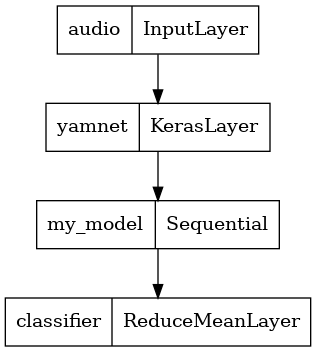

In [ ]:
tf.keras.utils.plot_model(serving_model)

Load your saved model to verify that it works as expected.

In [ ]:
reloaded_model = tf.saved_model.load(saved_model_path)

And for the final test: given some sound data, does your model return the correct result?

In [ ]:
reloaded_results = reloaded_model(testing_wav_data)
cat_or_dog = my_classes[tf.math.argmax(reloaded_results)]
print(f'The main sound is: {cat_or_dog}')

The main sound is: cat


If you want to try your new model on a serving setup, you can use the 'serving_default' signature.

In [ ]:
serving_results = reloaded_model.signatures['serving_default'](testing_wav_data)
cat_or_dog = my_classes[tf.math.argmax(serving_results['classifier'])]
print(f'The main sound is: {cat_or_dog}')


The main sound is: cat


## (Optional) Some more testing

The model is ready.

Let's compare it to YAMNet on the test dataset.

./datasets/ESC-50-master/audio/5-172299-A-5.wav


Waveform values: [-1.0854422e-06  3.1059460e-06 -1.3652678e-06 ...  1.6882542e-01
  1.3804492e-01  5.8870625e-02]


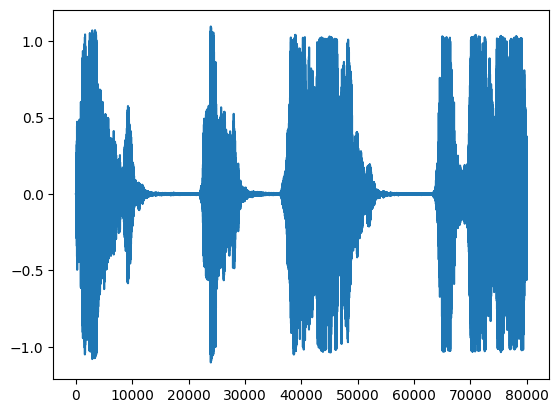

In [ ]:
test_pd = filtered_pd.loc[filtered_pd['fold'] == 5]
row = test_pd.sample(1)
filename = row['filename'].item()
print(filename)
waveform = load_wav_16k_mono(filename)
print(f'Waveform values: {waveform}')
_ = plt.plot(waveform)

display.Audio(waveform, rate=16000)

In [ ]:
# Run the model, check the output.
scores, embeddings, spectrogram = yamnet_model(waveform)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.math.argmax(class_scores)
inferred_class = class_names[top_class]
top_score = class_scores[top_class]
print(f'[YAMNet] The main sound is: {inferred_class} ({top_score})')

reloaded_results = reloaded_model(waveform)
your_top_class = tf.math.argmax(reloaded_results)
your_inferred_class = my_classes[your_top_class]
class_probabilities = tf.nn.softmax(reloaded_results, axis=-1)
your_top_score = class_probabilities[your_top_class]
print(f'[Your model] The main sound is: {your_inferred_class} ({your_top_score})')

[YAMNet] The main sound is: Domestic animals, pets (0.5051151514053345)
[Your model] The main sound is: cat (0.996594250202179)


## Next steps

You have created a model that can classify sounds from dogs or cats. With the same idea and a different dataset you can try, for example, building an [acoustic identifier of birds](https://www.kaggle.com/c/birdclef-2021/) based on their singing.

Share your project with the TensorFlow team on social media!
